In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import scipy.stats
import pandas as pd
import pyfish

In [2]:
font = {'family' : 'Helvetica Neue',
        'weight' : 'normal',
        'size'   : 30}

plt.rc('font', **font)

In [3]:
with open('correlation_data_export.pkl','rb') as file:
    df = pd.read_pickle('correlation_data_export.pkl')

In [4]:
freq_timeseries = np.loadtxt('data/wrightfisher_freq_timeseries_L10_N1000_T1000_mu0.01_trial0.csv',delimiter=',')
wf_ts = freq_timeseries.T

freq_timeseries = np.loadtxt('data/moran_freq_timeseries_L10_N1000_T1000_mu0.01_trial0.csv',delimiter=',')
moran_ts = freq_timeseries.T

freq_timeseries = np.loadtxt('data/serialdilution_freq_timeseries_L10_N1000_T1000_mu0.01_trial0.csv',delimiter=',')
sd_ts = freq_timeseries.T

with open('data/wrightfisher_processed_L10_N1000_T1000_mu0.01_trial0.pkl','rb') as file:
    wf_data = pickle.load(file)

with open('data/moran_processed_L10_N1000_T1000_mu0.01_trial0.pkl','rb') as file:
    moran_data = pickle.load(file)

with open('data/serialdilution_processed_L10_N1000_T1000_mu0.01_trial0.pkl','rb') as file:
    sd_data = pickle.load(file)

# main figure 1 

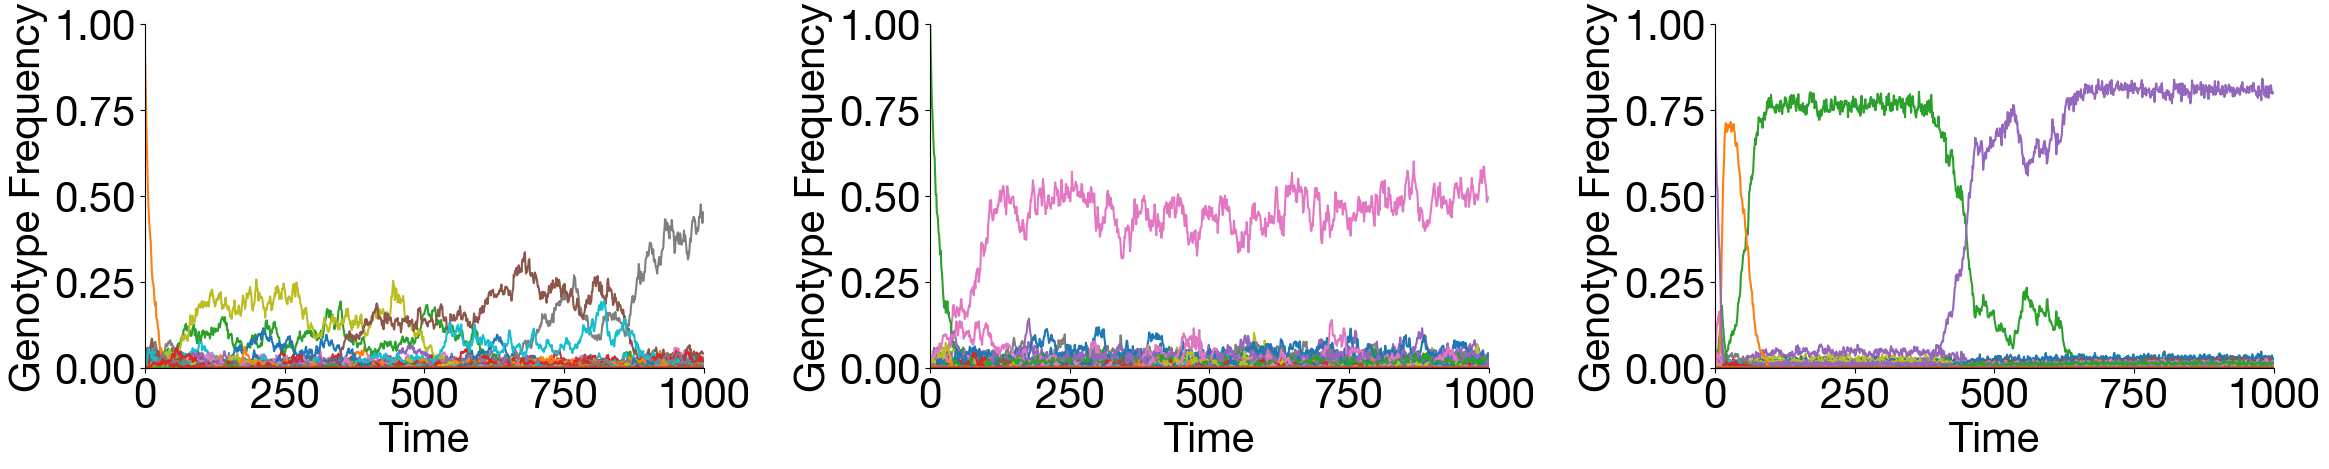

In [5]:
high_rare_cutoff = 10**(-3.5)
ypd_high_rare_cutoff = 10**(-3)
ypa_high_rare_cutoff = 10**(-3)

low_rare_cutoff = 10**(-5)
fig, axs = plt.subplots(1,3,figsize=(24,5.4))
plt.tight_layout()

# [Panel A] first row
axs[0].plot(wf_ts)
axs[0].set_xlim(0,wf_ts.shape[0])
axs[0].set_ylim(0,1)
axs[0].set_xlabel('Time')
axs[0].set_ylabel('Genotype Frequency')
axs[0].spines[['right', 'top']].set_visible(False)
# axs[0].set_title('Wright-Fisher',fontsize=30)

axs[1].plot(moran_ts)
axs[1].set_xlim(0,moran_ts.shape[0])
axs[1].set_ylim(0,1)
axs[1].set_xlabel('Time')
axs[1].set_ylabel('Genotype Frequency')
axs[1].spines[['right', 'top']].set_visible(False)
# axs[1].set_title('Moran',fontsize=30)

axs[2].plot(sd_ts)
axs[2].set_xlim(0,sd_ts.shape[0])
axs[2].set_ylim(0,1)
axs[2].set_xlabel('Time')
axs[2].set_ylabel('Genotype Frequency')
axs[2].spines[['right', 'top']].set_visible(False)
# axs[2].set_title('Serial Dilution/Chemostat',fontsize=30)

plt.tight_layout()
plt.savefig('paper_plots/sim_traj.pdf')

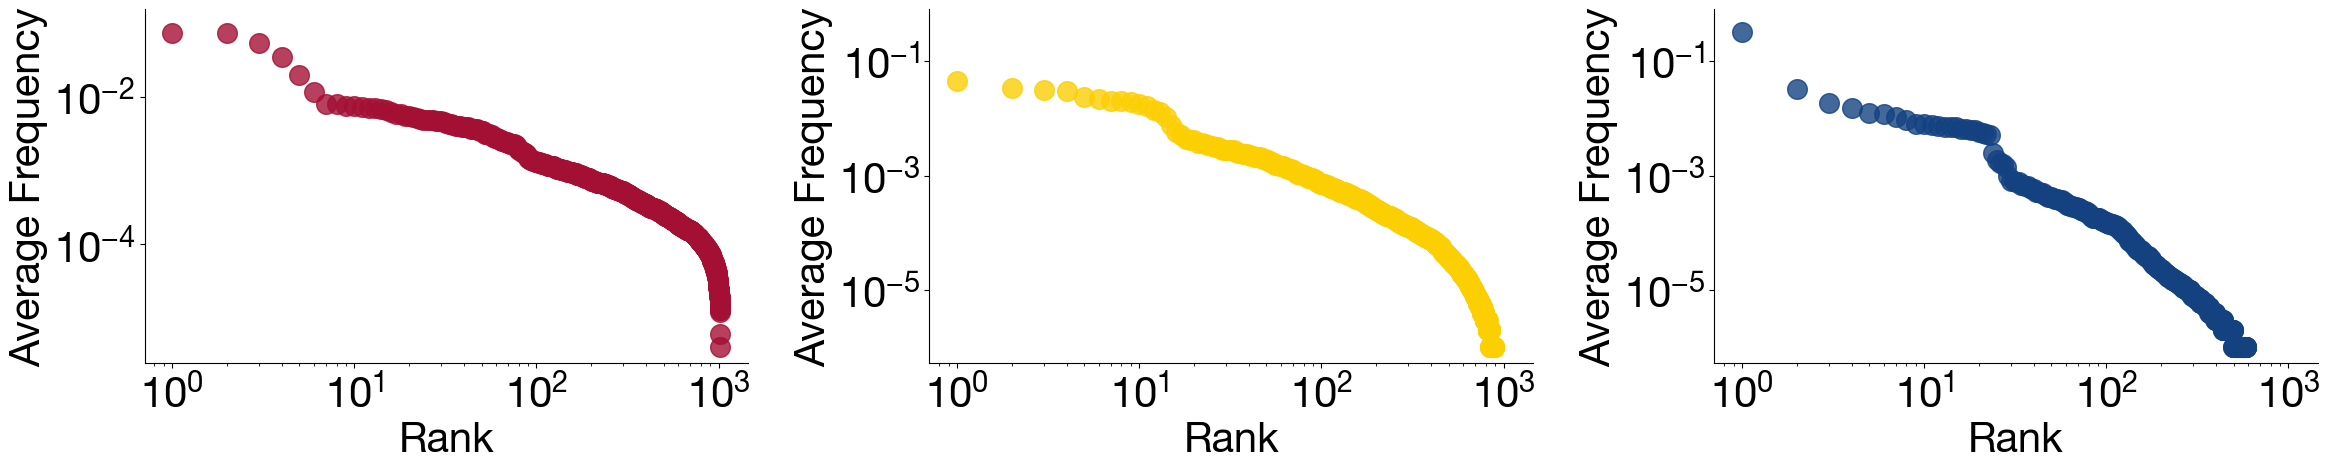

In [6]:
fig, axs = plt.subplots(1,3,figsize=(24,5.4))
plt.tight_layout()

## [Panel B] second row (frequency-rank plots)

x = np.arange(len(wf_data['timeavg_freq']))
y = np.flip(np.sort(wf_data['timeavg_freq']))
axs[0].scatter(x,y,alpha=0.8,s=200,c='#A41034')
axs[0].set_xlabel('Rank')
axs[0].set_ylabel('Average Frequency')
axs[0].set_xscale('log')
axs[0].set_yscale('log')
# axs[0].axhline(high_rare_cutoff,linestyle='--',color='grey', label='High Average Frequency Cutoff',linewidth=2,alpha=1)
# axs[0].axhline(low_rare_cutoff,linestyle='-',color='black', label='Low Average Frequency Cutoff',linewidth=2,alpha=1)
# axs[0].legend(loc="upper right", title=False, fontsize=18).get_frame().set_alpha(0)
axs[0].spines[['right', 'top']].set_visible(False)

x = np.arange(len(moran_data['timeavg_freq']))
y = np.flip(np.sort(moran_data['timeavg_freq']))
axs[1].scatter(x,y,alpha=0.8,s=200,c='#fccf03')
axs[1].set_xlabel('Rank')
axs[1].set_ylabel('Average Frequency')
axs[1].set_xscale('log')
axs[1].set_yscale('log')
# axs[1].axhline(high_rare_cutoff,linestyle='--',color='grey', label='High Average Frequency Cutoff',linewidth=2,alpha=1)
# axs[1].axhline(low_rare_cutoff,linestyle='-',color='black', label='Low Average Frequency Cutoff',linewidth=2,alpha=1)
# axs[1].legend(loc="upper right", title=False, fontsize=18).get_frame().set_alpha(0)
axs[1].spines[['right', 'top']].set_visible(False)

x = np.arange(len(sd_data['timeavg_freq']))
y = np.flip(np.sort(sd_data['timeavg_freq']))
axs[2].scatter(x,y,alpha=0.8,s=200,c='#144281')
axs[2].set_xlabel('Rank')
axs[2].set_ylabel('Average Frequency')
axs[2].set_xscale('log')
axs[2].set_yscale('log')
# axs[2].axhline(high_rare_cutoff,linestyle='--',color='grey', label='High Average Frequency Cutoff',linewidth=2,alpha=1)
# axs[2].axhline(low_rare_cutoff,linestyle='-',color='black', label='Low Average Frequency Cutoff',linewidth=2,alpha=1)
# axs[2].legend(loc="upper right", title=False, fontsize=18).get_frame().set_alpha(0)
axs[2].spines[['right', 'top']].set_visible(False)


plt.tight_layout()
plt.savefig('paper_plots/sim_rank_freq.pdf')

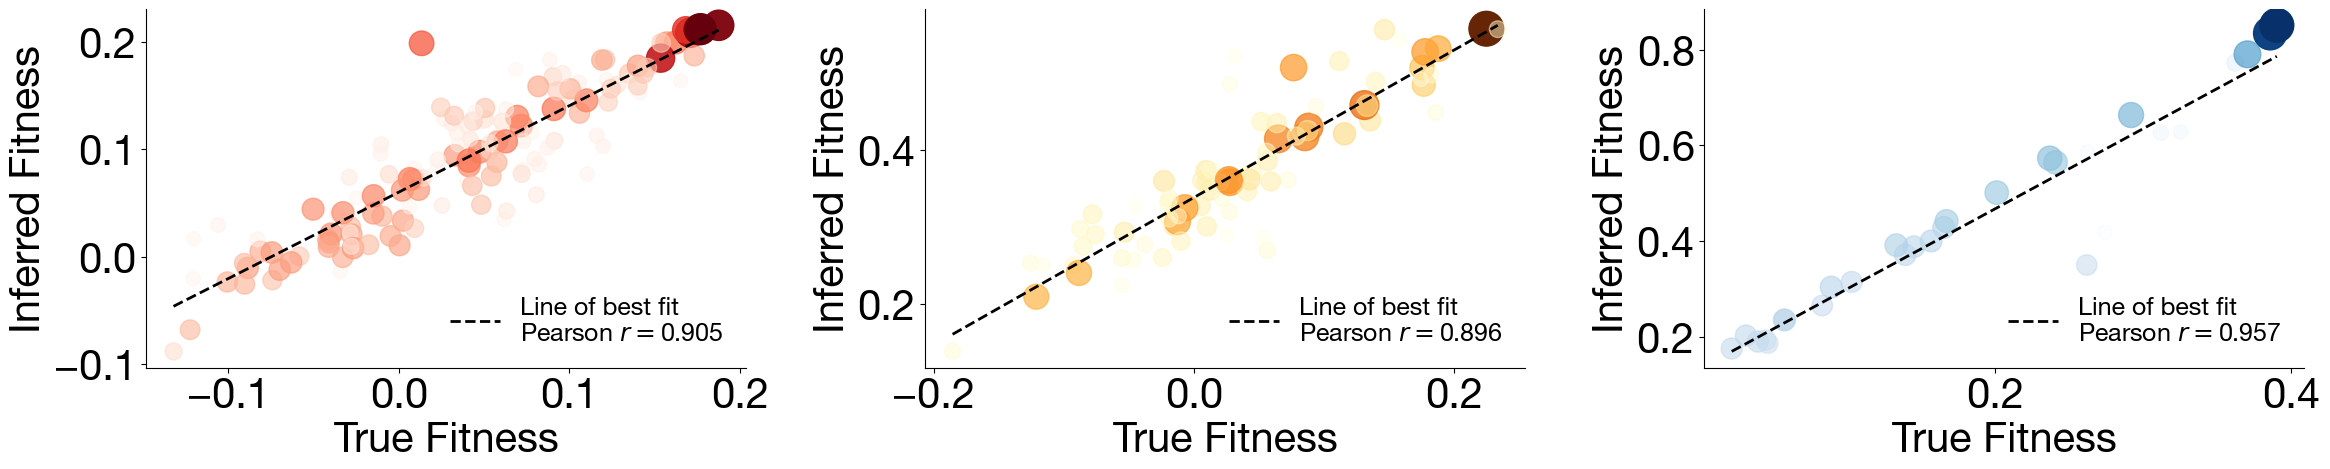

In [7]:
fig, axs = plt.subplots(1,3,figsize=(24,5.4))
plt.tight_layout()

rare_cutoff = 1e-3

## [Panel C] third row (high Average Frequency Cutoffs)

x = wf_data['F_real'][wf_data['timeavg_freq'] > rare_cutoff]
y = wf_data['F_est'][wf_data['timeavg_freq'] > rare_cutoff]
# axs[0].scatter(x,y,100,alpha=0.8, c='#A41034')
alphas=(2+np.log10(wf_data['timeavg_freq'][wf_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(wf_data['timeavg_freq'][wf_data['timeavg_freq'] > rare_cutoff])))/np.max((2+np.log10(wf_data['timeavg_freq'][wf_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(wf_data['timeavg_freq'][wf_data['timeavg_freq'] > rare_cutoff]))))
marker_sizes = 200*(1+np.log10(wf_data['timeavg_freq'][wf_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(wf_data['timeavg_freq'][wf_data['timeavg_freq'] > rare_cutoff])))-100
colors = 100+np.log10(wf_data['timeavg_freq'][wf_data['timeavg_freq'] > rare_cutoff])
axs[0].scatter(x,y,alpha=alphas,s=marker_sizes,c=colors,cmap='Reds')
# plt.xlim(3,5)
axs[0].set_xlabel('True Fitness')
axs[0].set_ylabel('Inferred Fitness')
# axs[0].set_ylim(-0.6,1)

pearson = scipy.stats.pearsonr(x, y)[0]

a, b = np.polyfit(x, y, 1)
xrange = np.linspace(np.min(x), np.max(x), 1000)
axs[0].plot(xrange, a*xrange+b, '--',color='black', label='Line of best fit\nPearson $r = $' + str(round(pearson,3)),linewidth=2,alpha=1)
axs[0].legend(loc="lower right", title=False, fontsize=18).get_frame().set_alpha(0)
axs[0].spines[['right', 'top']].set_visible(False)

x = moran_data['F_real'][moran_data['timeavg_freq'] > rare_cutoff]
y = moran_data['F_est'][moran_data['timeavg_freq'] > rare_cutoff]
# axs[1].scatter(x,y,100,alpha=0.8, c='#125C53')
alphas=(2+np.log10(moran_data['timeavg_freq'][moran_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(moran_data['timeavg_freq'][moran_data['timeavg_freq'] > rare_cutoff])))/np.max((2+np.log10(moran_data['timeavg_freq'][moran_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(moran_data['timeavg_freq'][moran_data['timeavg_freq'] > rare_cutoff]))))
marker_sizes = 200*(1+np.log10(moran_data['timeavg_freq'][moran_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(moran_data['timeavg_freq'][moran_data['timeavg_freq'] > rare_cutoff])))-100
colors = 100+np.log10(moran_data['timeavg_freq'][moran_data['timeavg_freq'] > rare_cutoff])
axs[1].scatter(x,y,alpha=alphas,s=marker_sizes,c=colors,cmap='YlOrBr')
# plt.xlim(3,5)
axs[1].set_xlabel('True Fitness')
axs[1].set_ylabel('Inferred Fitness')


pearson = scipy.stats.pearsonr(x, y)[0]

a, b = np.polyfit(x, y, 1)
xrange = np.linspace(np.min(x), np.max(x), 1000)
axs[1].plot(xrange, a*xrange+b,'--',color='black', label='Line of best fit\nPearson $r = $' + str(round(pearson,3)),linewidth=2,alpha=1)
axs[1].legend(loc="lower right", title=False, fontsize=18).get_frame().set_alpha(0)
axs[1].spines[['right', 'top']].set_visible(False)


x = sd_data['F_real'][sd_data['timeavg_freq'] > rare_cutoff]
y = sd_data['F_est'][sd_data['timeavg_freq'] > rare_cutoff]
# axs[2].scatter(x,y,100,alpha=0.8, c='#144281')
alphas=(2+np.log10(sd_data['timeavg_freq'][sd_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(sd_data['timeavg_freq'][sd_data['timeavg_freq'] > rare_cutoff])))/np.max((2+np.log10(sd_data['timeavg_freq'][sd_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(sd_data['timeavg_freq'][sd_data['timeavg_freq'] > rare_cutoff]))))
marker_sizes = 200*(1+np.log10(sd_data['timeavg_freq'][sd_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(sd_data['timeavg_freq'][sd_data['timeavg_freq'] > rare_cutoff])))-100
colors = 100+np.log10(sd_data['timeavg_freq'][sd_data['timeavg_freq'] > rare_cutoff])
axs[2].scatter(x,y,alpha=alphas,s=marker_sizes,c=colors,cmap='Blues')
# plt.xlim(3,5)
axs[2].set_xlabel('True Fitness')
axs[2].set_ylabel('Inferred Fitness')
# axs[2].set_ylim(-1.3,1.2)

pearson = scipy.stats.pearsonr(x, y)[0]

a, b = np.polyfit(x, y, 1)
xrange = np.linspace(np.min(x), np.max(x), 1000)
axs[2].plot(xrange, a*xrange+b,'--',color='black', label='Line of best fit\nPearson $r = $' + str(round(pearson,3)),linewidth=2,alpha=1)
axs[2].legend(loc="lower right", title=False, fontsize=18).get_frame().set_alpha(0)
axs[2].spines[['right', 'top']].set_visible(False)


plt.tight_layout()
plt.savefig('paper_plots/sim_high_cutoff.pdf')

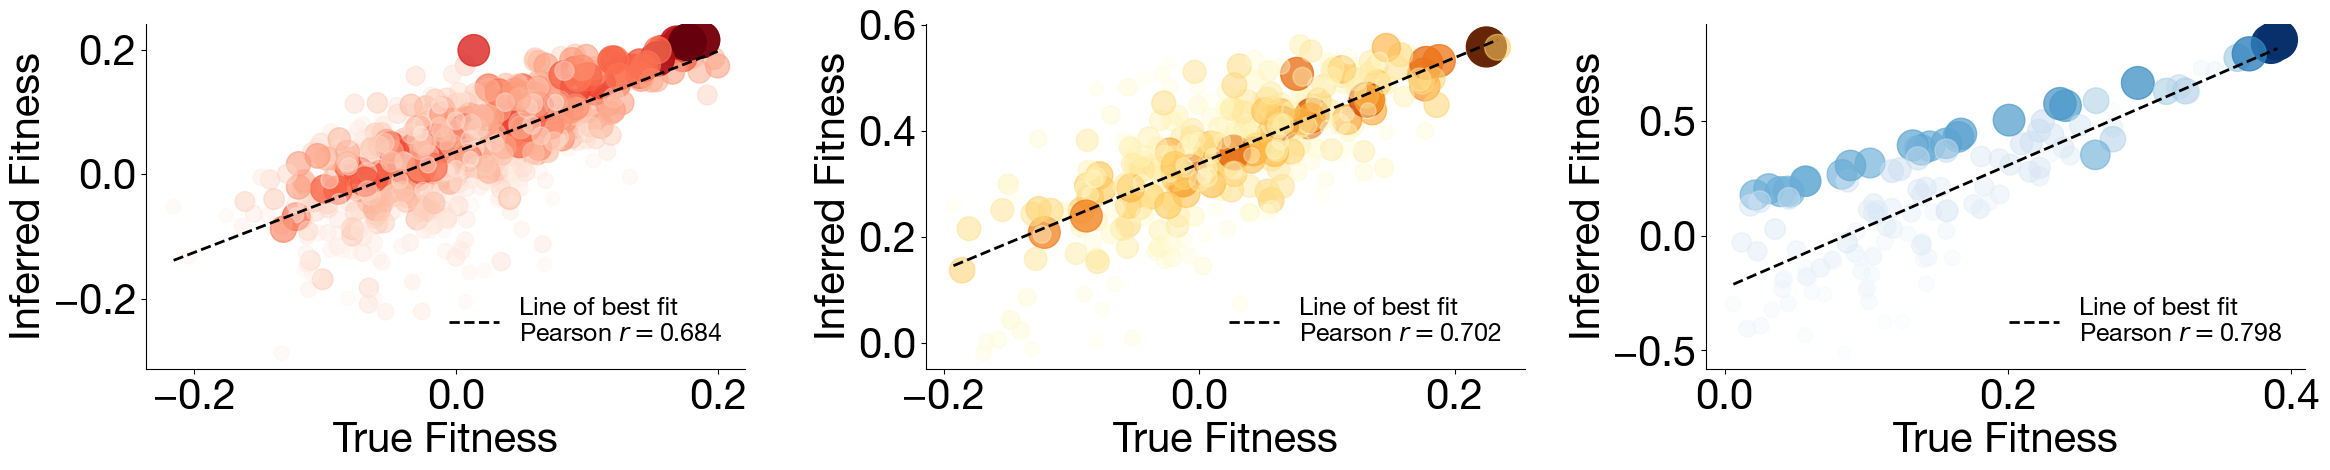

In [9]:
fig, axs = plt.subplots(1,3,figsize=(24,5.4))
plt.tight_layout()

rare_cutoff = 1e-4

## [Panel C] third row (high Average Frequency Cutoffs)

x = wf_data['F_real'][wf_data['timeavg_freq'] > rare_cutoff]
y = wf_data['F_est'][wf_data['timeavg_freq'] > rare_cutoff]
# axs[0].scatter(x,y,100,alpha=0.8, c='#A41034')
alphas=(2+np.log10(wf_data['timeavg_freq'][wf_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(wf_data['timeavg_freq'][wf_data['timeavg_freq'] > rare_cutoff])))/np.max((2+np.log10(wf_data['timeavg_freq'][wf_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(wf_data['timeavg_freq'][wf_data['timeavg_freq'] > rare_cutoff]))))
marker_sizes = 200*(1+np.log10(wf_data['timeavg_freq'][wf_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(wf_data['timeavg_freq'][wf_data['timeavg_freq'] > rare_cutoff])))-100
colors = 100+np.log10(wf_data['timeavg_freq'][wf_data['timeavg_freq'] > rare_cutoff])
axs[0].scatter(x,y,alpha=alphas,s=marker_sizes,c=colors,cmap='Reds')
# plt.xlim(3,5)
axs[0].set_xlabel('True Fitness')
axs[0].set_ylabel('Inferred Fitness')
# axs[0].set_ylim(-0.6,1)

pearson = scipy.stats.pearsonr(x, y)[0]

a, b = np.polyfit(x, y, 1)
xrange = np.linspace(np.min(x), np.max(x), 1000)
axs[0].plot(xrange, a*xrange+b, '--',color='black', label='Line of best fit\nPearson $r = $' + str(round(pearson,3)),linewidth=2,alpha=1)
axs[0].legend(loc="lower right", title=False, fontsize=18).get_frame().set_alpha(0)
axs[0].spines[['right', 'top']].set_visible(False)

x = moran_data['F_real'][moran_data['timeavg_freq'] > rare_cutoff]
y = moran_data['F_est'][moran_data['timeavg_freq'] > rare_cutoff]
# axs[1].scatter(x,y,100,alpha=0.8, c='#125C53')
alphas=(2+np.log10(moran_data['timeavg_freq'][moran_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(moran_data['timeavg_freq'][moran_data['timeavg_freq'] > rare_cutoff])))/np.max((2+np.log10(moran_data['timeavg_freq'][moran_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(moran_data['timeavg_freq'][moran_data['timeavg_freq'] > rare_cutoff]))))
marker_sizes = 200*(1+np.log10(moran_data['timeavg_freq'][moran_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(moran_data['timeavg_freq'][moran_data['timeavg_freq'] > rare_cutoff])))-100
colors = 100+np.log10(moran_data['timeavg_freq'][moran_data['timeavg_freq'] > rare_cutoff])
axs[1].scatter(x,y,alpha=alphas,s=marker_sizes,c=colors,cmap='YlOrBr')
# plt.xlim(3,5)
axs[1].set_xlabel('True Fitness')
axs[1].set_ylabel('Inferred Fitness')


pearson = scipy.stats.pearsonr(x, y)[0]

a, b = np.polyfit(x, y, 1)
xrange = np.linspace(np.min(x), np.max(x), 1000)
axs[1].plot(xrange, a*xrange+b,'--',color='black', label='Line of best fit\nPearson $r = $' + str(round(pearson,3)),linewidth=2,alpha=1)
axs[1].legend(loc="lower right", title=False, fontsize=18).get_frame().set_alpha(0)
axs[1].spines[['right', 'top']].set_visible(False)


x = sd_data['F_real'][sd_data['timeavg_freq'] > rare_cutoff]
y = sd_data['F_est'][sd_data['timeavg_freq'] > rare_cutoff]
# axs[2].scatter(x,y,100,alpha=0.8, c='#144281')
alphas=(2+np.log10(sd_data['timeavg_freq'][sd_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(sd_data['timeavg_freq'][sd_data['timeavg_freq'] > rare_cutoff])))/np.max((2+np.log10(sd_data['timeavg_freq'][sd_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(sd_data['timeavg_freq'][sd_data['timeavg_freq'] > rare_cutoff]))))
marker_sizes = 200*(1+np.log10(sd_data['timeavg_freq'][sd_data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(sd_data['timeavg_freq'][sd_data['timeavg_freq'] > rare_cutoff])))-100
colors = 100+np.log10(sd_data['timeavg_freq'][sd_data['timeavg_freq'] > rare_cutoff])
axs[2].scatter(x,y,alpha=alphas,s=marker_sizes,c=colors,cmap='Blues')
# plt.xlim(3,5)
axs[2].set_xlabel('True Fitness')
axs[2].set_ylabel('Inferred Fitness')
# axs[2].set_ylim(-1.3,1.2)

pearson = scipy.stats.pearsonr(x, y)[0]

a, b = np.polyfit(x, y, 1)
xrange = np.linspace(np.min(x), np.max(x), 1000)
axs[2].plot(xrange, a*xrange+b,'--',color='black', label='Line of best fit\nPearson $r = $' + str(round(pearson,3)),linewidth=2,alpha=1)
axs[2].legend(loc="lower right", title=False, fontsize=18).get_frame().set_alpha(0)
axs[2].spines[['right', 'top']].set_visible(False)

plt.tight_layout()
plt.savefig('paper_plots/sim_low_cutoff.pdf')

# aggregated data

## N = 1000, T = 1000

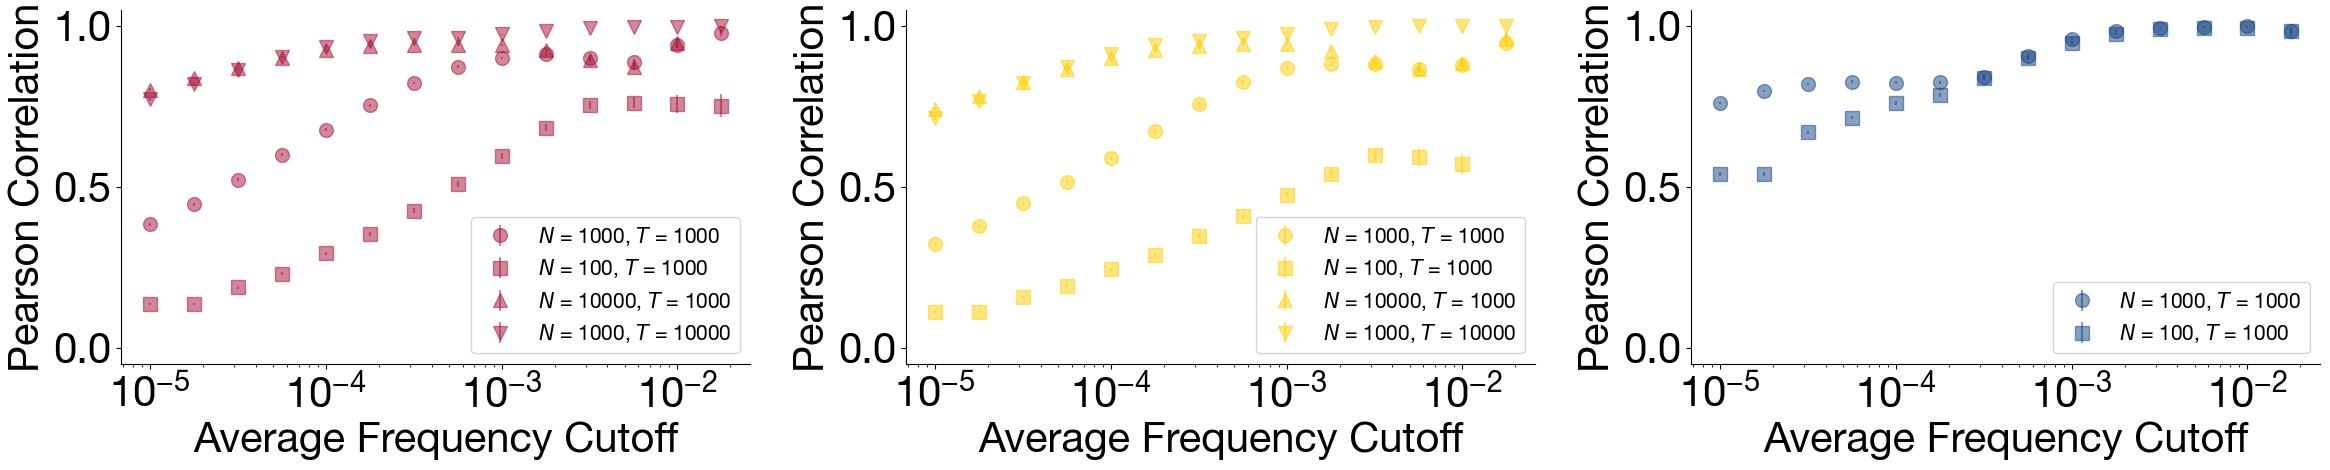

In [53]:
Npop = 1000
Tsim = 1000
cutoffs_to_keep = 14

current_df = df[
    (df['model'] == 'wrightfisher') &
    (df['N'] == Npop) & 
    (df['T'] == Tsim)
].reset_index(drop=True)

Ntrials = current_df.shape[0]
Ndata = current_df['correlation_data'][0].shape[0]

pearson_table = np.zeros((Ndata, Ntrials))
N_common_variants_table = np.zeros((Ndata, Ntrials))
rare_cutoffs_log10 = current_df['correlation_data'][0]['rare_cutoffs_log10'].to_numpy()[:cutoffs_to_keep]

for i in range(current_df.shape[0]):
    correlation_data = current_df['correlation_data'][i]
    pearson_table[:,i] = correlation_data['pearson_values'].to_numpy()
    N_common_variants_table[:,i] = correlation_data['N_common_variants'].to_numpy()

pearson_means = np.mean(pearson_table, axis=1)[:cutoffs_to_keep]
pearson_sterrs = np.std(pearson_table, axis=1, ddof=1)[:cutoffs_to_keep] / np.sqrt(Ntrials)
Npoints_means = np.mean(N_common_variants_table, axis=1)[:cutoffs_to_keep]
Npoints_sterrs = np.std(N_common_variants_table, axis=1,)[:cutoffs_to_keep] / np.sqrt(Ntrials)

fig, axs = plt.subplots(1,3,figsize=(24,5.4))
plt.tight_layout()

x = 10**rare_cutoffs_log10
y = pearson_means
yerr = pearson_sterrs
axs[0].errorbar(x=x,y=y,yerr=yerr,marker='o',alpha=0.5,markersize=10,linestyle='',c='#A41034',label='$N$ = ' + str(Npop) + ', $T$ = ' + str(Tsim))
axs[0].set_xlabel('Average Frequency Cutoff')
axs[0].set_ylabel('Pearson Correlation')
axs[0].set_xscale('log')
axs[0].spines[['right', 'top']].set_visible(False)
axs[0].set_ylim(0.25,1.05)

current_df = df[
    (df['model'] == 'moran') &
    (df['N'] == Npop) & 
    (df['T'] == Tsim)
].reset_index(drop=True)

Ntrials = current_df.shape[0]
Ndata = current_df['correlation_data'][0].shape[0]

pearson_table = np.zeros((Ndata, Ntrials))
N_common_variants_table = np.zeros((Ndata, Ntrials))
rare_cutoffs_log10 = current_df['correlation_data'][0]['rare_cutoffs_log10'].to_numpy()[0:cutoffs_to_keep]

for i in range(current_df.shape[0]):
    correlation_data = current_df['correlation_data'][i]
    pearson_table[:,i] = correlation_data['pearson_values'].to_numpy()
    N_common_variants_table[:,i] = correlation_data['N_common_variants'].to_numpy()

pearson_means = np.mean(pearson_table, axis=1)[0:cutoffs_to_keep]
pearson_sterrs = np.std(pearson_table, axis=1, ddof=1)[0:cutoffs_to_keep] / np.sqrt(Ntrials)
Npoints_means = np.mean(N_common_variants_table, axis=1)[0:cutoffs_to_keep]
Npoints_sterrs = np.std(N_common_variants_table, axis=1)[0:cutoffs_to_keep] / np.sqrt(Ntrials)

x = 10**rare_cutoffs_log10
y = pearson_means
yerr = pearson_sterrs
axs[1].errorbar(x=x,y=y,yerr=yerr,marker='o',alpha=0.5,markersize=10,linestyle='',c='#fccf03',label='$N$ = ' + str(Npop) + ', $T$ = ' + str(Tsim))
axs[1].set_xlabel('Average Frequency Cutoff')
axs[1].set_ylabel('Pearson Correlation')
axs[1].set_xscale('log')
axs[1].spines[['right', 'top']].set_visible(False)
axs[1].set_ylim(0.25,1.05)

current_df = df[
    (df['model'] == 'serialdilution') &
    (df['N'] == Npop) & 
    (df['T'] == Tsim)
].reset_index(drop=True)

Ntrials = current_df.shape[0]
Ndata = current_df['correlation_data'][0].shape[0]

pearson_table = np.zeros((Ndata, Ntrials))
N_common_variants_table = np.zeros((Ndata, Ntrials))
rare_cutoffs_log10 = current_df['correlation_data'][0]['rare_cutoffs_log10'].to_numpy()[:cutoffs_to_keep]

for i in range(current_df.shape[0]):
    correlation_data = current_df['correlation_data'][i]
    pearson_table[:,i] = correlation_data['pearson_values'].to_numpy()
    N_common_variants_table[:,i] = correlation_data['N_common_variants'].to_numpy()

pearson_means = np.mean(pearson_table, axis=1)[:cutoffs_to_keep]
pearson_sterrs = np.std(pearson_table, axis=1, ddof=1)[:cutoffs_to_keep] / np.sqrt(Ntrials)
Npoints_means = np.mean(N_common_variants_table, axis=1)[:cutoffs_to_keep]
Npoints_sterrs = np.std(N_common_variants_table, axis=1,)[:cutoffs_to_keep] / np.sqrt(Ntrials)

x = 10**rare_cutoffs_log10
y = pearson_means
yerr = pearson_sterrs
axs[2].errorbar(x=x,y=y,yerr=yerr,marker='o',alpha=0.5,markersize=10,linestyle='',c='#144281',label='$N$ = ' + str(Npop) + ', $T$ = ' + str(Tsim))
axs[2].set_xlabel('Average Frequency Cutoff')
axs[2].set_ylabel('Pearson Correlation')
axs[2].set_xscale('log')
axs[2].spines[['right', 'top']].set_visible(False)
axs[2].set_ylim(0.25,1.05)

# plt.tight_layout()
# plt.show()
# plt.savefig('paper_plots/sim_pearson_N' + str(Npop) + '_T' + str(Tsim) + '.pdf')


Npop = 100
Tsim = 1000
cutoffs_to_keep = 14

current_df = df[
    (df['model'] == 'wrightfisher') &
    (df['N'] == Npop) & 
    (df['T'] == Tsim)
].reset_index(drop=True)

Ntrials = current_df.shape[0]
Ndata = current_df['correlation_data'][0].shape[0]

pearson_table = np.zeros((Ndata, Ntrials))
N_common_variants_table = np.zeros((Ndata, Ntrials))
rare_cutoffs_log10 = current_df['correlation_data'][0]['rare_cutoffs_log10'].to_numpy()[:cutoffs_to_keep]

for i in range(current_df.shape[0]):
    correlation_data = current_df['correlation_data'][i]
    pearson_table[:,i] = correlation_data['pearson_values'].to_numpy()
    N_common_variants_table[:,i] = correlation_data['N_common_variants'].to_numpy()

pearson_means = np.mean(pearson_table, axis=1)[:cutoffs_to_keep]
pearson_sterrs = np.std(pearson_table, axis=1, ddof=1)[:cutoffs_to_keep] / np.sqrt(Ntrials)
Npoints_means = np.mean(N_common_variants_table, axis=1)[:cutoffs_to_keep]
Npoints_sterrs = np.std(N_common_variants_table, axis=1,)[:cutoffs_to_keep] / np.sqrt(Ntrials)



x = 10**rare_cutoffs_log10
y = pearson_means
yerr = pearson_sterrs
axs[0].errorbar(x=x,y=y,yerr=yerr,marker='s',alpha=0.5,markersize=10,linestyle='',c='#A41034',label='$N$ = ' + str(Npop) + ', $T$ = ' + str(Tsim))
axs[0].set_xlabel('Average Frequency Cutoff')
axs[0].set_ylabel('Pearson Correlation')
axs[0].set_xscale('log')
axs[0].spines[['right', 'top']].set_visible(False)
axs[0].set_ylim(-0.05,1.05)

current_df = df[
    (df['model'] == 'moran') &
    (df['N'] == Npop) & 
    (df['T'] == Tsim)
].reset_index(drop=True)

Ntrials = current_df.shape[0]
Ndata = current_df['correlation_data'][0].shape[0]

pearson_table = np.zeros((Ndata, Ntrials))
N_common_variants_table = np.zeros((Ndata, Ntrials))
rare_cutoffs_log10 = current_df['correlation_data'][0]['rare_cutoffs_log10'].to_numpy()[0:cutoffs_to_keep]

for i in range(current_df.shape[0]):
    correlation_data = current_df['correlation_data'][i]
    pearson_table[:,i] = correlation_data['pearson_values'].to_numpy()
    N_common_variants_table[:,i] = correlation_data['N_common_variants'].to_numpy()

pearson_means = np.mean(pearson_table, axis=1)[0:cutoffs_to_keep]
pearson_sterrs = np.std(pearson_table, axis=1, ddof=1)[0:cutoffs_to_keep] / np.sqrt(Ntrials)
Npoints_means = np.mean(N_common_variants_table, axis=1)[0:cutoffs_to_keep]
Npoints_sterrs = np.std(N_common_variants_table, axis=1)[0:cutoffs_to_keep] / np.sqrt(Ntrials)

x = 10**rare_cutoffs_log10
y = pearson_means
yerr = pearson_sterrs
axs[1].errorbar(x=x,y=y,yerr=yerr,marker='s',alpha=0.5,markersize=10,linestyle='',c='#fccf03',label='$N$ = ' + str(Npop) + ', $T$ = ' + str(Tsim))
axs[1].set_xlabel('Average Frequency Cutoff')
axs[1].set_ylabel('Pearson Correlation')
axs[1].set_xscale('log')
axs[1].spines[['right', 'top']].set_visible(False)
axs[1].set_ylim(-0.05,1.05)

current_df = df[
    (df['model'] == 'serialdilution') &
    (df['N'] == Npop) & 
    (df['T'] == Tsim)
].reset_index(drop=True)

Ntrials = current_df.shape[0]
Ndata = current_df['correlation_data'][0].shape[0]

pearson_table = np.zeros((Ndata, Ntrials))
N_common_variants_table = np.zeros((Ndata, Ntrials))
rare_cutoffs_log10 = current_df['correlation_data'][0]['rare_cutoffs_log10'].to_numpy()[:cutoffs_to_keep]

for i in range(current_df.shape[0]):
    correlation_data = current_df['correlation_data'][i]
    pearson_table[:,i] = correlation_data['pearson_values'].to_numpy()
    N_common_variants_table[:,i] = correlation_data['N_common_variants'].to_numpy()

pearson_means = np.mean(pearson_table, axis=1)[:cutoffs_to_keep]
pearson_sterrs = np.std(pearson_table, axis=1, ddof=1)[:cutoffs_to_keep] / np.sqrt(Ntrials)
Npoints_means = np.mean(N_common_variants_table, axis=1)[:cutoffs_to_keep]
Npoints_sterrs = np.std(N_common_variants_table, axis=1,)[:cutoffs_to_keep] / np.sqrt(Ntrials)

x = 10**rare_cutoffs_log10
y = pearson_means
yerr = pearson_sterrs
axs[2].errorbar(x=x,y=y,yerr=yerr,marker='s',alpha=0.5,markersize=10,linestyle='',c='#144281',label='$N$ = ' + str(Npop) + ', $T$ = ' + str(Tsim))
axs[2].set_xlabel('Average Frequency Cutoff')
axs[2].set_ylabel('Pearson Correlation')
axs[2].set_xscale('log')
axs[2].spines[['right', 'top']].set_visible(False)
axs[2].set_ylim(-0.05,1.05)


####### Npop = 10000 #######

Npop = 10000
Tsim = 1000
cutoffs_to_keep = 14

current_df = df[
    (df['model'] == 'wrightfisher') &
    (df['N'] == Npop) & 
    (df['T'] == Tsim)
].reset_index(drop=True)

Ntrials = current_df.shape[0]
Ndata = current_df['correlation_data'][0].shape[0]

pearson_table = np.zeros((Ndata, Ntrials))
N_common_variants_table = np.zeros((Ndata, Ntrials))
rare_cutoffs_log10 = current_df['correlation_data'][0]['rare_cutoffs_log10'].to_numpy()[:cutoffs_to_keep]

for i in range(current_df.shape[0]):
    correlation_data = current_df['correlation_data'][i]
    pearson_table[:,i] = correlation_data['pearson_values'].to_numpy()
    N_common_variants_table[:,i] = correlation_data['N_common_variants'].to_numpy()

pearson_means = np.mean(pearson_table, axis=1)[:cutoffs_to_keep]
pearson_sterrs = np.std(pearson_table, axis=1, ddof=1)[:cutoffs_to_keep] / np.sqrt(Ntrials)
Npoints_means = np.mean(N_common_variants_table, axis=1)[:cutoffs_to_keep]
Npoints_sterrs = np.std(N_common_variants_table, axis=1,)[:cutoffs_to_keep] / np.sqrt(Ntrials)

# fig, axs = plt.subplots(1,3,figsize=(24,5.4))
# plt.tight_layout()

x = 10**rare_cutoffs_log10
y = pearson_means
yerr = pearson_sterrs
axs[0].errorbar(x=x,y=y,yerr=yerr,marker='^',alpha=0.5,markersize=10,linestyle='',c='#A41034',label='$N$ = ' + str(Npop) + ', $T$ = ' + str(Tsim))
axs[0].set_xlabel('Average Frequency Cutoff')
axs[0].set_ylabel('Pearson Correlation')
axs[0].set_xscale('log')
axs[0].spines[['right', 'top']].set_visible(False)
axs[0].set_ylim(-0.05,1.05)

current_df = df[
    (df['model'] == 'moran') &
    (df['N'] == Npop) & 
    (df['T'] == Tsim)
].reset_index(drop=True)

Ntrials = current_df.shape[0]
Ndata = current_df['correlation_data'][0].shape[0]

pearson_table = np.zeros((Ndata, Ntrials))
N_common_variants_table = np.zeros((Ndata, Ntrials))
rare_cutoffs_log10 = current_df['correlation_data'][0]['rare_cutoffs_log10'].to_numpy()[0:cutoffs_to_keep]

for i in range(current_df.shape[0]):
    correlation_data = current_df['correlation_data'][i]
    pearson_table[:,i] = correlation_data['pearson_values'].to_numpy()
    N_common_variants_table[:,i] = correlation_data['N_common_variants'].to_numpy()

pearson_means = np.mean(pearson_table, axis=1)[0:cutoffs_to_keep]
pearson_sterrs = np.std(pearson_table, axis=1, ddof=1)[0:cutoffs_to_keep] / np.sqrt(Ntrials)
Npoints_means = np.mean(N_common_variants_table, axis=1)[0:cutoffs_to_keep]
Npoints_sterrs = np.std(N_common_variants_table, axis=1)[0:cutoffs_to_keep] / np.sqrt(Ntrials)

x = 10**rare_cutoffs_log10
y = pearson_means
yerr = pearson_sterrs
axs[1].errorbar(x=x,y=y,yerr=yerr,marker='^',alpha=0.5,markersize=10,linestyle='',c='#fccf03',label='$N$ = ' + str(Npop) + ', $T$ = ' + str(Tsim))
axs[1].set_xlabel('Average Frequency Cutoff')
axs[1].set_ylabel('Pearson Correlation')
axs[1].set_xscale('log')
axs[1].spines[['right', 'top']].set_visible(False)
axs[1].set_ylim(-0.05,1.05)

# current_df = df[
#     (df['model'] == 'serialdilution') &
#     (df['N'] == Npop) & 
#     (df['T'] == Tsim)
# ].reset_index(drop=True)

# Ntrials = current_df.shape[0]
# Ndata = current_df['correlation_data'][0].shape[0]

# pearson_table = np.zeros((Ndata, Ntrials))
# N_common_variants_table = np.zeros((Ndata, Ntrials))
# rare_cutoffs_log10 = current_df['correlation_data'][0]['rare_cutoffs_log10'].to_numpy()[:cutoffs_to_keep]

# for i in range(current_df.shape[0]):
#     correlation_data = current_df['correlation_data'][i]
#     pearson_table[:,i] = correlation_data['pearson_values'].to_numpy()
#     N_common_variants_table[:,i] = correlation_data['N_common_variants'].to_numpy()

# pearson_means = np.mean(pearson_table, axis=1)[:cutoffs_to_keep]
# pearson_sterrs = np.std(pearson_table, axis=1, ddof=1)[:cutoffs_to_keep] / np.sqrt(Ntrials)
# Npoints_means = np.mean(N_common_variants_table, axis=1)[:cutoffs_to_keep]
# Npoints_sterrs = np.std(N_common_variants_table, axis=1,)[:cutoffs_to_keep] / np.sqrt(Ntrials)

# x = 10**rare_cutoffs_log10
# y = pearson_means
# yerr = pearson_sterrs
# axs[2].errorbar(x=x,y=y,yerr=yerr,marker='s',alpha=0.5,markersize=10,linestyle='',c='#144281')
# axs[2].set_xlabel('Average Frequency Cutoff')
# axs[2].set_ylabel('Pearson Correlation')
# axs[2].set_xscale('log')
# axs[2].spines[['right', 'top']].set_visible(False)
# axs[2].set_ylim(-0.05,1.05)

####### Npop = 10000 #######

Npop = 1000
Tsim = 10000
cutoffs_to_keep = 14

current_df = df[
    (df['model'] == 'wrightfisher') &
    (df['N'] == Npop) & 
    (df['T'] == Tsim)
].reset_index(drop=True)

Ntrials = current_df.shape[0]
Ndata = current_df['correlation_data'][0].shape[0]

pearson_table = np.zeros((Ndata, Ntrials))
N_common_variants_table = np.zeros((Ndata, Ntrials))
rare_cutoffs_log10 = current_df['correlation_data'][0]['rare_cutoffs_log10'].to_numpy()[:cutoffs_to_keep]

for i in range(current_df.shape[0]):
    correlation_data = current_df['correlation_data'][i]
    pearson_table[:,i] = correlation_data['pearson_values'].to_numpy()
    N_common_variants_table[:,i] = correlation_data['N_common_variants'].to_numpy()

pearson_means = np.mean(pearson_table, axis=1)[:cutoffs_to_keep]
pearson_sterrs = np.std(pearson_table, axis=1, ddof=1)[:cutoffs_to_keep] / np.sqrt(Ntrials)
Npoints_means = np.mean(N_common_variants_table, axis=1)[:cutoffs_to_keep]
Npoints_sterrs = np.std(N_common_variants_table, axis=1,)[:cutoffs_to_keep] / np.sqrt(Ntrials)

# fig, axs = plt.subplots(1,3,figsize=(24,5.4))
# plt.tight_layout()

x = 10**rare_cutoffs_log10
y = pearson_means
yerr = pearson_sterrs
axs[0].errorbar(x=x,y=y,yerr=yerr,marker='v',alpha=0.5,markersize=10,linestyle='',c='#A41034',label='$N$ = ' + str(Npop) + ', $T$ = ' + str(Tsim))
axs[0].set_xlabel('Average Frequency Cutoff')
axs[0].set_ylabel('Pearson Correlation')
axs[0].set_xscale('log')
axs[0].spines[['right', 'top']].set_visible(False)
axs[0].set_ylim(-0.05,1.05)

current_df = df[
    (df['model'] == 'moran') &
    (df['N'] == Npop) & 
    (df['T'] == Tsim)
].reset_index(drop=True)

Ntrials = current_df.shape[0]
Ndata = current_df['correlation_data'][0].shape[0]

pearson_table = np.zeros((Ndata, Ntrials))
N_common_variants_table = np.zeros((Ndata, Ntrials))
rare_cutoffs_log10 = current_df['correlation_data'][0]['rare_cutoffs_log10'].to_numpy()[0:cutoffs_to_keep]

for i in range(current_df.shape[0]):
    correlation_data = current_df['correlation_data'][i]
    pearson_table[:,i] = correlation_data['pearson_values'].to_numpy()
    N_common_variants_table[:,i] = correlation_data['N_common_variants'].to_numpy()

pearson_means = np.mean(pearson_table, axis=1)[0:cutoffs_to_keep]
pearson_sterrs = np.std(pearson_table, axis=1, ddof=1)[0:cutoffs_to_keep] / np.sqrt(Ntrials)
Npoints_means = np.mean(N_common_variants_table, axis=1)[0:cutoffs_to_keep]
Npoints_sterrs = np.std(N_common_variants_table, axis=1)[0:cutoffs_to_keep] / np.sqrt(Ntrials)

x = 10**rare_cutoffs_log10
y = pearson_means
yerr = pearson_sterrs
axs[1].errorbar(x=x,y=y,yerr=yerr,marker='v',alpha=0.5,markersize=10,linestyle='',c='#fccf03',label='$N$ = ' + str(Npop) + ', $T$ = ' + str(Tsim))
axs[1].set_xlabel('Average Frequency Cutoff')
axs[1].set_ylabel('Pearson Correlation')
axs[1].set_xscale('log')
axs[1].spines[['right', 'top']].set_visible(False)
axs[1].set_ylim(-0.05,1.05)

# current_df = df[
#     (df['model'] == 'serialdilution') &
#     (df['N'] == Npop) & 
#     (df['T'] == Tsim)
# ].reset_index(drop=True)

# Ntrials = current_df.shape[0]
# Ndata = current_df['correlation_data'][0].shape[0]

# pearson_table = np.zeros((Ndata, Ntrials))
# N_common_variants_table = np.zeros((Ndata, Ntrials))
# rare_cutoffs_log10 = current_df['correlation_data'][0]['rare_cutoffs_log10'].to_numpy()[:cutoffs_to_keep]

# for i in range(current_df.shape[0]):
#     correlation_data = current_df['correlation_data'][i]
#     pearson_table[:,i] = correlation_data['pearson_values'].to_numpy()
#     N_common_variants_table[:,i] = correlation_data['N_common_variants'].to_numpy()

# pearson_means = np.mean(pearson_table, axis=1)[:cutoffs_to_keep]
# pearson_sterrs = np.std(pearson_table, axis=1, ddof=1)[:cutoffs_to_keep] / np.sqrt(Ntrials)
# Npoints_means = np.mean(N_common_variants_table, axis=1)[:cutoffs_to_keep]
# Npoints_sterrs = np.std(N_common_variants_table, axis=1,)[:cutoffs_to_keep] / np.sqrt(Ntrials)

# x = 10**rare_cutoffs_log10
# y = pearson_means
# yerr = pearson_sterrs
# axs[2].errorbar(x=x,y=y,yerr=yerr,marker='s',alpha=0.5,markersize=10,linestyle='',c='#144281')
# axs[2].set_xlabel('Average Frequency Cutoff')
# axs[2].set_ylabel('Pearson Correlation')
# axs[2].set_xscale('log')
# axs[2].spines[['right', 'top']].set_visible(False)
# axs[2].set_ylim(-0.05,1.05)
axs[0].legend(loc='lower right',fontsize=15)
axs[1].legend(loc='lower right',fontsize=15)
axs[2].legend(loc='lower right',fontsize=15)

plt.tight_layout()
plt.savefig('paper_plots/sim_pearson_N.pdf')

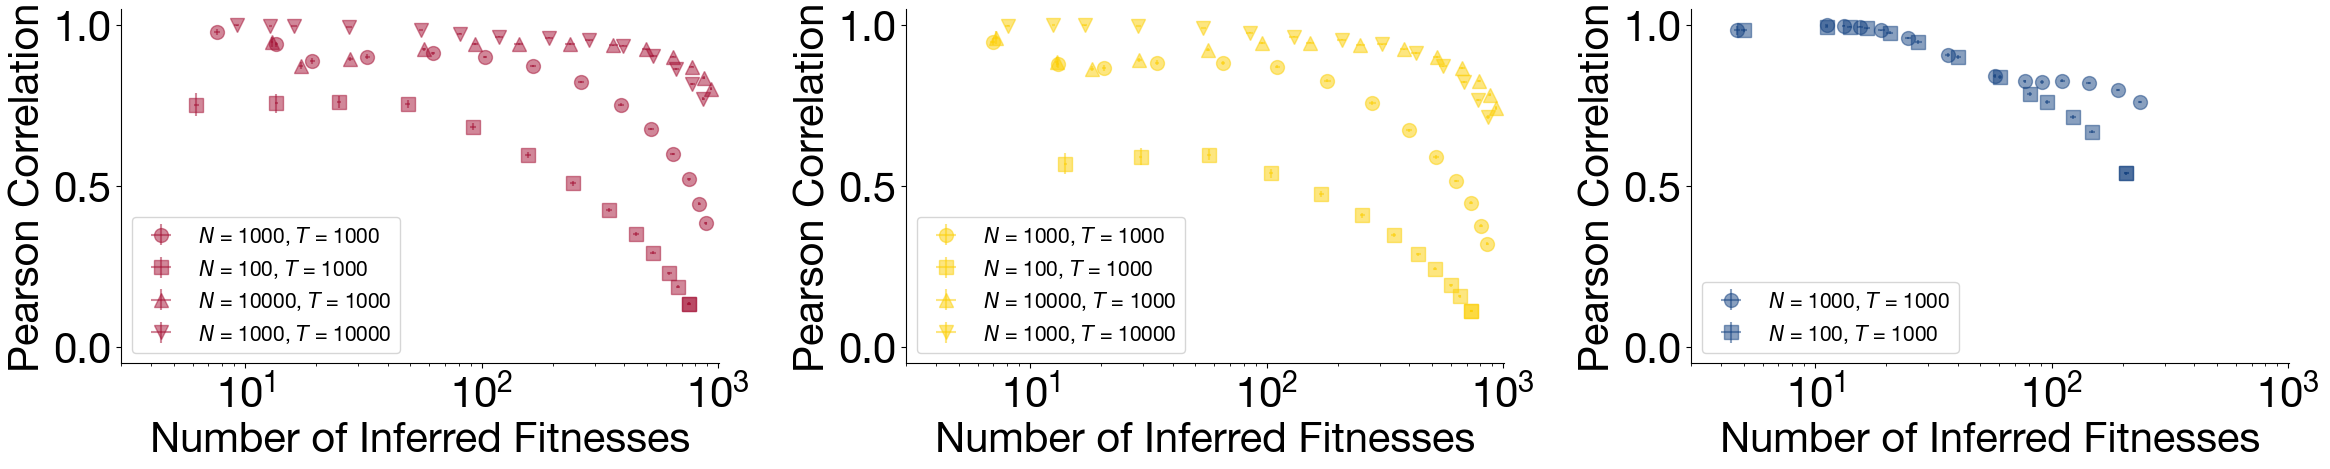

In [54]:
Npop = 1000
Tsim = 1000
cutoffs_to_keep = 14

current_df = df[
    (df['model'] == 'wrightfisher') &
    (df['N'] == Npop) & 
    (df['T'] == Tsim)
].reset_index(drop=True)

Ntrials = current_df.shape[0]
Ndata = current_df['correlation_data'][0].shape[0]

pearson_table = np.zeros((Ndata, Ntrials))
N_common_variants_table = np.zeros((Ndata, Ntrials))
rare_cutoffs_log10 = current_df['correlation_data'][0]['rare_cutoffs_log10'].to_numpy()[:cutoffs_to_keep]

for i in range(current_df.shape[0]):
    correlation_data = current_df['correlation_data'][i]
    pearson_table[:,i] = correlation_data['pearson_values'].to_numpy()
    N_common_variants_table[:,i] = correlation_data['N_common_variants'].to_numpy()

pearson_means = np.mean(pearson_table, axis=1)[:cutoffs_to_keep]
pearson_sterrs = np.std(pearson_table, axis=1, ddof=1)[:cutoffs_to_keep] / np.sqrt(Ntrials)
Npoints_means = np.mean(N_common_variants_table, axis=1)[:cutoffs_to_keep]
Npoints_sterrs = np.std(N_common_variants_table, axis=1,)[:cutoffs_to_keep] / np.sqrt(Ntrials)

fig, axs = plt.subplots(1,3,figsize=(24,5.4))
plt.tight_layout()

x = Npoints_means
xerr = Npoints_sterrs
y = pearson_means
yerr = pearson_sterrs
axs[0].errorbar(x=x,y=y,xerr=xerr,yerr=yerr,marker='o',alpha=0.5,markersize=10,linestyle='',c='#A41034',label='$N$ = ' + str(Npop) + ', $T$ = ' + str(Tsim))
axs[0].set_xlabel('Number of Inferred Fitnesses')
axs[0].set_ylabel('Pearson Correlation')
axs[0].set_xscale('log')
axs[0].spines[['right', 'top']].set_visible(False)
axs[0].set_ylim(0.25,1.05)

current_df = df[
    (df['model'] == 'moran') &
    (df['N'] == Npop) & 
    (df['T'] == Tsim)
].reset_index(drop=True)

Ntrials = current_df.shape[0]
Ndata = current_df['correlation_data'][0].shape[0]

pearson_table = np.zeros((Ndata, Ntrials))
N_common_variants_table = np.zeros((Ndata, Ntrials))
rare_cutoffs_log10 = current_df['correlation_data'][0]['rare_cutoffs_log10'].to_numpy()[0:cutoffs_to_keep]

for i in range(current_df.shape[0]):
    correlation_data = current_df['correlation_data'][i]
    pearson_table[:,i] = correlation_data['pearson_values'].to_numpy()
    N_common_variants_table[:,i] = correlation_data['N_common_variants'].to_numpy()

pearson_means = np.mean(pearson_table, axis=1)[0:cutoffs_to_keep]
pearson_sterrs = np.std(pearson_table, axis=1, ddof=1)[0:cutoffs_to_keep] / np.sqrt(Ntrials)
Npoints_means = np.mean(N_common_variants_table, axis=1)[0:cutoffs_to_keep]
Npoints_sterrs = np.std(N_common_variants_table, axis=1)[0:cutoffs_to_keep] / np.sqrt(Ntrials)

x = Npoints_means
xerr = Npoints_sterrs
y = pearson_means
yerr = pearson_sterrs
axs[1].errorbar(x=x,y=y,xerr=xerr,yerr=yerr,marker='o',alpha=0.5,markersize=10,linestyle='',c='#fccf03',label='$N$ = ' + str(Npop) + ', $T$ = ' + str(Tsim))
axs[1].set_xlabel('Number of Inferred Fitnesses')
axs[1].set_ylabel('Pearson Correlation')
axs[1].set_xscale('log')
axs[1].spines[['right', 'top']].set_visible(False)
axs[1].set_ylim(0.25,1.05)

current_df = df[
    (df['model'] == 'serialdilution') &
    (df['N'] == Npop) & 
    (df['T'] == Tsim)
].reset_index(drop=True)

Ntrials = current_df.shape[0]
Ndata = current_df['correlation_data'][0].shape[0]

pearson_table = np.zeros((Ndata, Ntrials))
N_common_variants_table = np.zeros((Ndata, Ntrials))
rare_cutoffs_log10 = current_df['correlation_data'][0]['rare_cutoffs_log10'].to_numpy()[:cutoffs_to_keep]

for i in range(current_df.shape[0]):
    correlation_data = current_df['correlation_data'][i]
    pearson_table[:,i] = correlation_data['pearson_values'].to_numpy()
    N_common_variants_table[:,i] = correlation_data['N_common_variants'].to_numpy()

pearson_means = np.mean(pearson_table, axis=1)[:cutoffs_to_keep]
pearson_sterrs = np.std(pearson_table, axis=1, ddof=1)[:cutoffs_to_keep] / np.sqrt(Ntrials)
Npoints_means = np.mean(N_common_variants_table, axis=1)[:cutoffs_to_keep]
Npoints_sterrs = np.std(N_common_variants_table, axis=1,)[:cutoffs_to_keep] / np.sqrt(Ntrials)

x = Npoints_means
xerr = Npoints_sterrs
y = pearson_means
yerr = pearson_sterrs
axs[2].errorbar(x=x,y=y,xerr=xerr,yerr=yerr,marker='o',alpha=0.5,markersize=10,linestyle='',c='#144281',label='$N$ = ' + str(Npop) + ', $T$ = ' + str(Tsim))
axs[2].set_xlabel('Number of Inferred Fitnesses')
axs[2].set_ylabel('Pearson Correlation')
axs[2].set_xscale('log')
axs[2].spines[['right', 'top']].set_visible(False)
axs[2].set_ylim(0.25,1.05)

# plt.tight_layout()
# plt.show()
# plt.savefig('paper_plots/sim_pearson_N' + str(Npop) + '_T' + str(Tsim) + '.pdf')


Npop = 100
Tsim = 1000
cutoffs_to_keep = 14

current_df = df[
    (df['model'] == 'wrightfisher') &
    (df['N'] == Npop) & 
    (df['T'] == Tsim)
].reset_index(drop=True)

Ntrials = current_df.shape[0]
Ndata = current_df['correlation_data'][0].shape[0]

pearson_table = np.zeros((Ndata, Ntrials))
N_common_variants_table = np.zeros((Ndata, Ntrials))
rare_cutoffs_log10 = current_df['correlation_data'][0]['rare_cutoffs_log10'].to_numpy()[:cutoffs_to_keep]

for i in range(current_df.shape[0]):
    correlation_data = current_df['correlation_data'][i]
    pearson_table[:,i] = correlation_data['pearson_values'].to_numpy()
    N_common_variants_table[:,i] = correlation_data['N_common_variants'].to_numpy()

pearson_means = np.mean(pearson_table, axis=1)[:cutoffs_to_keep]
pearson_sterrs = np.std(pearson_table, axis=1, ddof=1)[:cutoffs_to_keep] / np.sqrt(Ntrials)
Npoints_means = np.mean(N_common_variants_table, axis=1)[:cutoffs_to_keep]
Npoints_sterrs = np.std(N_common_variants_table, axis=1,)[:cutoffs_to_keep] / np.sqrt(Ntrials)



x = Npoints_means
xerr = Npoints_sterrs
y = pearson_means
yerr = pearson_sterrs
axs[0].errorbar(x=x,y=y,xerr=xerr,yerr=yerr,marker='s',alpha=0.5,markersize=10,linestyle='',c='#A41034',label='$N$ = ' + str(Npop) + ', $T$ = ' + str(Tsim))
axs[0].set_xlabel('Number of Inferred Fitnesses')
axs[0].set_ylabel('Pearson Correlation')
axs[0].set_xscale('log')
axs[0].spines[['right', 'top']].set_visible(False)
axs[0].set_xlim(3,1005)
axs[0].set_ylim(-0.05,1.05)

current_df = df[
    (df['model'] == 'moran') &
    (df['N'] == Npop) & 
    (df['T'] == Tsim)
].reset_index(drop=True)

Ntrials = current_df.shape[0]
Ndata = current_df['correlation_data'][0].shape[0]

pearson_table = np.zeros((Ndata, Ntrials))
N_common_variants_table = np.zeros((Ndata, Ntrials))
rare_cutoffs_log10 = current_df['correlation_data'][0]['rare_cutoffs_log10'].to_numpy()[0:cutoffs_to_keep]

for i in range(current_df.shape[0]):
    correlation_data = current_df['correlation_data'][i]
    pearson_table[:,i] = correlation_data['pearson_values'].to_numpy()
    N_common_variants_table[:,i] = correlation_data['N_common_variants'].to_numpy()

pearson_means = np.mean(pearson_table, axis=1)[0:cutoffs_to_keep]
pearson_sterrs = np.std(pearson_table, axis=1, ddof=1)[0:cutoffs_to_keep] / np.sqrt(Ntrials)
Npoints_means = np.mean(N_common_variants_table, axis=1)[0:cutoffs_to_keep]
Npoints_sterrs = np.std(N_common_variants_table, axis=1)[0:cutoffs_to_keep] / np.sqrt(Ntrials)

x = Npoints_means
xerr = Npoints_sterrs
y = pearson_means
yerr = pearson_sterrs
axs[1].errorbar(x=x,y=y,xerr=xerr,yerr=yerr,marker='s',alpha=0.5,markersize=10,linestyle='',c='#fccf03',label='$N$ = ' + str(Npop) + ', $T$ = ' + str(Tsim))
axs[1].set_xlabel('Number of Inferred Fitnesses')
axs[1].set_ylabel('Pearson Correlation')
axs[1].set_xscale('log')
axs[1].spines[['right', 'top']].set_visible(False)
axs[1].set_xlim(3,1005)
axs[1].set_ylim(-0.05,1.05)

current_df = df[
    (df['model'] == 'serialdilution') &
    (df['N'] == Npop) & 
    (df['T'] == Tsim)
].reset_index(drop=True)

Ntrials = current_df.shape[0]
Ndata = current_df['correlation_data'][0].shape[0]

pearson_table = np.zeros((Ndata, Ntrials))
N_common_variants_table = np.zeros((Ndata, Ntrials))
rare_cutoffs_log10 = current_df['correlation_data'][0]['rare_cutoffs_log10'].to_numpy()[:cutoffs_to_keep]

for i in range(current_df.shape[0]):
    correlation_data = current_df['correlation_data'][i]
    pearson_table[:,i] = correlation_data['pearson_values'].to_numpy()
    N_common_variants_table[:,i] = correlation_data['N_common_variants'].to_numpy()

pearson_means = np.mean(pearson_table, axis=1)[:cutoffs_to_keep]
pearson_sterrs = np.std(pearson_table, axis=1, ddof=1)[:cutoffs_to_keep] / np.sqrt(Ntrials)
Npoints_means = np.mean(N_common_variants_table, axis=1)[:cutoffs_to_keep]
Npoints_sterrs = np.std(N_common_variants_table, axis=1,)[:cutoffs_to_keep] / np.sqrt(Ntrials)

x = Npoints_means
xerr = Npoints_sterrs
y = pearson_means
yerr = pearson_sterrs
axs[2].errorbar(x=x,y=y,xerr=xerr,yerr=yerr,marker='s',alpha=0.5,markersize=10,linestyle='',c='#144281',label='$N$ = ' + str(Npop) + ', $T$ = ' + str(Tsim))
axs[2].set_xlabel('Number of Inferred Fitnesses')
axs[2].set_ylabel('Pearson Correlation')
axs[2].set_xscale('log')
axs[2].spines[['right', 'top']].set_visible(False)
axs[2].set_xlim(3,1005)
axs[2].set_ylim(-0.05,1.05)


####### Npop = 10000 #######

Npop = 10000
Tsim = 1000
cutoffs_to_keep = 14

current_df = df[
    (df['model'] == 'wrightfisher') &
    (df['N'] == Npop) & 
    (df['T'] == Tsim)
].reset_index(drop=True)

Ntrials = current_df.shape[0]
Ndata = current_df['correlation_data'][0].shape[0]

pearson_table = np.zeros((Ndata, Ntrials))
N_common_variants_table = np.zeros((Ndata, Ntrials))
rare_cutoffs_log10 = current_df['correlation_data'][0]['rare_cutoffs_log10'].to_numpy()[:cutoffs_to_keep]

for i in range(current_df.shape[0]):
    correlation_data = current_df['correlation_data'][i]
    pearson_table[:,i] = correlation_data['pearson_values'].to_numpy()
    N_common_variants_table[:,i] = correlation_data['N_common_variants'].to_numpy()

pearson_means = np.mean(pearson_table, axis=1)[:cutoffs_to_keep]
pearson_sterrs = np.std(pearson_table, axis=1, ddof=1)[:cutoffs_to_keep] / np.sqrt(Ntrials)
Npoints_means = np.mean(N_common_variants_table, axis=1)[:cutoffs_to_keep]
Npoints_sterrs = np.std(N_common_variants_table, axis=1,)[:cutoffs_to_keep] / np.sqrt(Ntrials)

# fig, axs = plt.subplots(1,3,figsize=(24,5.4))
# plt.tight_layout()

x = Npoints_means
xerr = Npoints_sterrs
y = pearson_means
yerr = pearson_sterrs
axs[0].errorbar(x=x,y=y,xerr=xerr,yerr=yerr,marker='^',alpha=0.5,markersize=10,linestyle='',c='#A41034',label='$N$ = ' + str(Npop) + ', $T$ = ' + str(Tsim))
axs[0].set_xlabel('Number of Inferred Fitnesses')
axs[0].set_ylabel('Pearson Correlation')
axs[0].set_xscale('log')
axs[0].spines[['right', 'top']].set_visible(False)
axs[0].set_xlim(3,1005)
axs[0].set_ylim(-0.05,1.05)

current_df = df[
    (df['model'] == 'moran') &
    (df['N'] == Npop) & 
    (df['T'] == Tsim)
].reset_index(drop=True)

Ntrials = current_df.shape[0]
Ndata = current_df['correlation_data'][0].shape[0]

pearson_table = np.zeros((Ndata, Ntrials))
N_common_variants_table = np.zeros((Ndata, Ntrials))
rare_cutoffs_log10 = current_df['correlation_data'][0]['rare_cutoffs_log10'].to_numpy()[0:cutoffs_to_keep]

for i in range(current_df.shape[0]):
    correlation_data = current_df['correlation_data'][i]
    pearson_table[:,i] = correlation_data['pearson_values'].to_numpy()
    N_common_variants_table[:,i] = correlation_data['N_common_variants'].to_numpy()

pearson_means = np.mean(pearson_table, axis=1)[0:cutoffs_to_keep]
pearson_sterrs = np.std(pearson_table, axis=1, ddof=1)[0:cutoffs_to_keep] / np.sqrt(Ntrials)
Npoints_means = np.mean(N_common_variants_table, axis=1)[0:cutoffs_to_keep]
Npoints_sterrs = np.std(N_common_variants_table, axis=1)[0:cutoffs_to_keep] / np.sqrt(Ntrials)

x = Npoints_means
xerr = Npoints_sterrs
y = pearson_means
yerr = pearson_sterrs
axs[1].errorbar(x=x,y=y,xerr=xerr,yerr=yerr,marker='^',alpha=0.5,markersize=10,linestyle='',c='#fccf03',label='$N$ = ' + str(Npop) + ', $T$ = ' + str(Tsim))
axs[1].set_xlabel('Number of Inferred Fitnesses')
axs[1].set_ylabel('Pearson Correlation')
axs[1].set_xscale('log')
axs[1].spines[['right', 'top']].set_visible(False)
axs[1].set_xlim(3,1005)
axs[1].set_ylim(-0.05,1.05)

# current_df = df[
#     (df['model'] == 'serialdilution') &
#     (df['N'] == Npop) & 
#     (df['T'] == Tsim)
# ].reset_index(drop=True)

# Ntrials = current_df.shape[0]
# Ndata = current_df['correlation_data'][0].shape[0]

# pearson_table = np.zeros((Ndata, Ntrials))
# N_common_variants_table = np.zeros((Ndata, Ntrials))
# rare_cutoffs_log10 = current_df['correlation_data'][0]['rare_cutoffs_log10'].to_numpy()[:cutoffs_to_keep]

# for i in range(current_df.shape[0]):
#     correlation_data = current_df['correlation_data'][i]
#     pearson_table[:,i] = correlation_data['pearson_values'].to_numpy()
#     N_common_variants_table[:,i] = correlation_data['N_common_variants'].to_numpy()

# pearson_means = np.mean(pearson_table, axis=1)[:cutoffs_to_keep]
# pearson_sterrs = np.std(pearson_table, axis=1, ddof=1)[:cutoffs_to_keep] / np.sqrt(Ntrials)
# Npoints_means = np.mean(N_common_variants_table, axis=1)[:cutoffs_to_keep]
# Npoints_sterrs = np.std(N_common_variants_table, axis=1,)[:cutoffs_to_keep] / np.sqrt(Ntrials)

# x = Npoints_means
xerr = Npoints_sterrs
# y = pearson_means
# yerr = pearson_sterrs
# axs[2].errorbar(x=x,y=y,xerr=xerr,yerr=yerr,marker='s',alpha=0.5,markersize=10,linestyle='',c='#144281')
# axs[2].set_xlabel('Number of Inferred Fitnesses')
# axs[2].set_ylabel('Pearson Correlation')
# axs[2].set_xscale('log')
# axs[2].spines[['right', 'top']].set_visible(False)
# axs[2].set_xlim(3,1005)
axs[2].set_ylim(-0.05,1.05)

####### Npop = 10000 #######

Npop = 1000
Tsim = 10000
cutoffs_to_keep = 14

current_df = df[
    (df['model'] == 'wrightfisher') &
    (df['N'] == Npop) & 
    (df['T'] == Tsim)
].reset_index(drop=True)

Ntrials = current_df.shape[0]
Ndata = current_df['correlation_data'][0].shape[0]

pearson_table = np.zeros((Ndata, Ntrials))
N_common_variants_table = np.zeros((Ndata, Ntrials))
rare_cutoffs_log10 = current_df['correlation_data'][0]['rare_cutoffs_log10'].to_numpy()[:cutoffs_to_keep]

for i in range(current_df.shape[0]):
    correlation_data = current_df['correlation_data'][i]
    pearson_table[:,i] = correlation_data['pearson_values'].to_numpy()
    N_common_variants_table[:,i] = correlation_data['N_common_variants'].to_numpy()

pearson_means = np.mean(pearson_table, axis=1)[:cutoffs_to_keep]
pearson_sterrs = np.std(pearson_table, axis=1, ddof=1)[:cutoffs_to_keep] / np.sqrt(Ntrials)
Npoints_means = np.mean(N_common_variants_table, axis=1)[:cutoffs_to_keep]
Npoints_sterrs = np.std(N_common_variants_table, axis=1,)[:cutoffs_to_keep] / np.sqrt(Ntrials)

# fig, axs = plt.subplots(1,3,figsize=(24,5.4))
# plt.tight_layout()

x = Npoints_means
xerr = Npoints_sterrs
y = pearson_means
yerr = pearson_sterrs
axs[0].errorbar(x=x,y=y,xerr=xerr,yerr=yerr,marker='v',alpha=0.5,markersize=10,linestyle='',c='#A41034',label='$N$ = ' + str(Npop) + ', $T$ = ' + str(Tsim))
axs[0].set_xlabel('Number of Inferred Fitnesses')
axs[0].set_ylabel('Pearson Correlation')
axs[0].set_xscale('log')
axs[0].spines[['right', 'top']].set_visible(False)
axs[0].set_xlim(3,1005)
axs[0].set_ylim(-0.05,1.05)

current_df = df[
    (df['model'] == 'moran') &
    (df['N'] == Npop) & 
    (df['T'] == Tsim)
].reset_index(drop=True)

Ntrials = current_df.shape[0]
Ndata = current_df['correlation_data'][0].shape[0]

pearson_table = np.zeros((Ndata, Ntrials))
N_common_variants_table = np.zeros((Ndata, Ntrials))
rare_cutoffs_log10 = current_df['correlation_data'][0]['rare_cutoffs_log10'].to_numpy()[0:cutoffs_to_keep]

for i in range(current_df.shape[0]):
    correlation_data = current_df['correlation_data'][i]
    pearson_table[:,i] = correlation_data['pearson_values'].to_numpy()
    N_common_variants_table[:,i] = correlation_data['N_common_variants'].to_numpy()

pearson_means = np.mean(pearson_table, axis=1)[0:cutoffs_to_keep]
pearson_sterrs = np.std(pearson_table, axis=1, ddof=1)[0:cutoffs_to_keep] / np.sqrt(Ntrials)
Npoints_means = np.mean(N_common_variants_table, axis=1)[0:cutoffs_to_keep]
Npoints_sterrs = np.std(N_common_variants_table, axis=1)[0:cutoffs_to_keep] / np.sqrt(Ntrials)

x = Npoints_means
xerr = Npoints_sterrs
y = pearson_means
yerr = pearson_sterrs
axs[1].errorbar(x=x,y=y,xerr=xerr,yerr=yerr,marker='v',alpha=0.5,markersize=10,linestyle='',c='#fccf03',label='$N$ = ' + str(Npop) + ', $T$ = ' + str(Tsim))
axs[1].set_xlabel('Number of Inferred Fitnesses')
axs[1].set_ylabel('Pearson Correlation')
axs[1].set_xscale('log')
axs[1].spines[['right', 'top']].set_visible(False)
axs[1].set_xlim(3,1005)
axs[1].set_ylim(-0.05,1.05)

# current_df = df[
#     (df['model'] == 'serialdilution') &
#     (df['N'] == Npop) & 
#     (df['T'] == Tsim)
# ].reset_index(drop=True)

# Ntrials = current_df.shape[0]
# Ndata = current_df['correlation_data'][0].shape[0]

# pearson_table = np.zeros((Ndata, Ntrials))
# N_common_variants_table = np.zeros((Ndata, Ntrials))
# rare_cutoffs_log10 = current_df['correlation_data'][0]['rare_cutoffs_log10'].to_numpy()[:cutoffs_to_keep]

# for i in range(current_df.shape[0]):
#     correlation_data = current_df['correlation_data'][i]
#     pearson_table[:,i] = correlation_data['pearson_values'].to_numpy()
#     N_common_variants_table[:,i] = correlation_data['N_common_variants'].to_numpy()

# pearson_means = np.mean(pearson_table, axis=1)[:cutoffs_to_keep]
# pearson_sterrs = np.std(pearson_table, axis=1, ddof=1)[:cutoffs_to_keep] / np.sqrt(Ntrials)
# Npoints_means = np.mean(N_common_variants_table, axis=1)[:cutoffs_to_keep]
# Npoints_sterrs = np.std(N_common_variants_table, axis=1,)[:cutoffs_to_keep] / np.sqrt(Ntrials)

# x = Npoints_means
xerr = Npoints_sterrs
# y = pearson_means
# yerr = pearson_sterrs
# axs[2].errorbar(x=x,y=y,xerr=xerr,yerr=yerr,marker='s',alpha=0.5,markersize=10,linestyle='',c='#144281')
# axs[2].set_xlabel('Number of Inferred Fitnesses')
# axs[2].set_ylabel('Pearson Correlation')
# axs[2].set_xscale('log')
# axs[2].spines[['right', 'top']].set_visible(False)
# axs[2].set_xlim(3,1005)
axs[2].set_ylim(-0.05,1.05)
axs[0].legend(loc='lower left',fontsize=15)
axs[1].legend(loc='lower left',fontsize=15)
axs[2].legend(loc='lower left',fontsize=15)

plt.tight_layout()
plt.savefig('paper_plots/sim_numpoints.pdf')

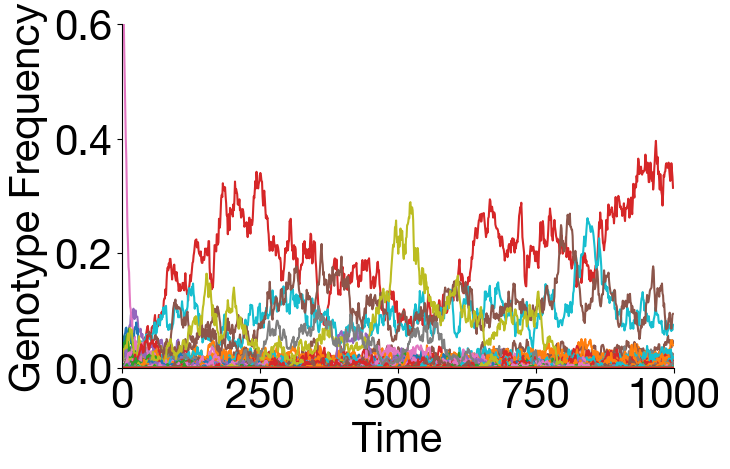

In [56]:
freq_timeseries = np.loadtxt('data/wrightfisher_freq_timeseries_L10_N1000_T1000_mu0.01_trial16.csv',delimiter=',')
sd_ts_schematic = freq_timeseries.T

fig, axs = plt.subplots(figsize=(8,5.4))
plt.plot(sd_ts_schematic)

plt.xlim(0,freq_timeseries.shape[1])
plt.ylim(0,0.6)
axs.spines[['right', 'top']].set_visible(False)
plt.xlabel('Time')
plt.ylabel('Genotype Frequency')
plt.tight_layout()
plt.savefig('paper_plots/stochastic.pdf')

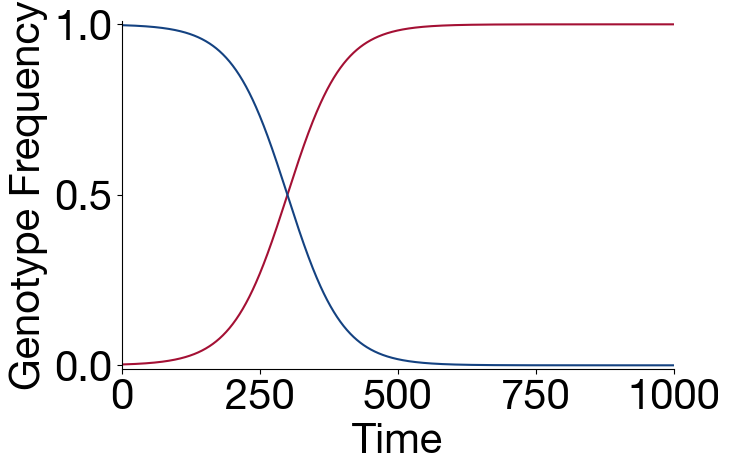

In [57]:
fig, axs = plt.subplots(figsize=(8,5.4))
xrange = np.arange(1000)
plt.plot(xrange,np.exp(0.02*(xrange-300))/(1+ np.exp(0.02*(xrange-300))),c='#A41034')
plt.plot(xrange,1 - np.exp(0.02*(xrange-300))/(1+ np.exp(0.02*(xrange-300))),c='#144281')
plt.xlim(0,1000)
plt.ylim(-0.01,1.01)
plt.xlabel('Time')
plt.ylabel('Genotype Frequency')
axs.spines[['right', 'top']].set_visible(False)
plt.tight_layout()
plt.savefig('paper_plots/logistic.pdf')